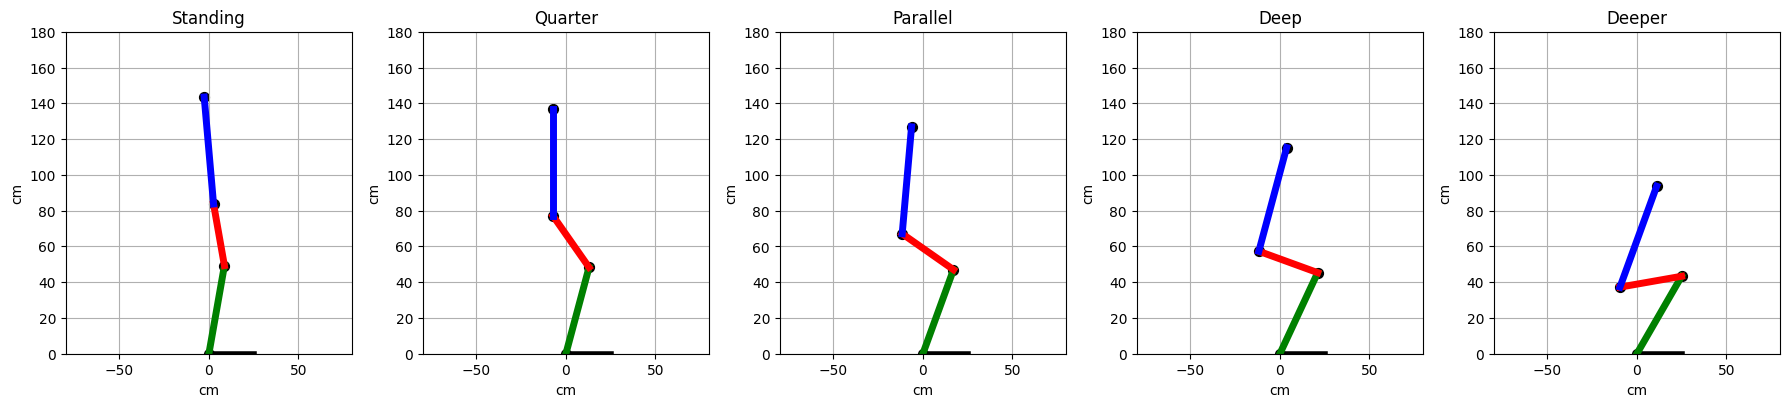

In [32]:
import numpy as np
import matplotlib.pyplot as plt


def draw_leg(ax, ankle, tibia, femur, torso,
             shin_deg, femur_deg, torso_deg):

    # Convert to radians
    shin = np.radians(shin_deg)
    fem = np.radians(femur_deg)
    tor = np.radians(torso_deg)

    ankle = np.array(ankle)

    # Joint positions
    knee = ankle + tibia * np.array([np.cos(shin), np.sin(shin)])
    hip = knee + femur * np.array([np.cos(fem), np.sin(fem)])
    shoulder = hip + torso * np.array([np.cos(tor), np.sin(tor)])

    # Foot
    toe = ankle + np.array([25, 0])

    # Segments
    ax.plot([ankle[0], toe[0]], [ankle[1], toe[1]], lw=4, color="black", label="Foot")
    ax.plot([ankle[0], knee[0]], [ankle[1], knee[1]], lw=5, color="green", label="Tibia")
    ax.plot([knee[0], hip[0]], [knee[1], hip[1]], lw=5, color="red", label="Femur")
    ax.plot([hip[0], shoulder[0]], [hip[1], shoulder[1]], lw=5, color="blue", label="Torso")

    # Joints
    for p in [ankle, knee, hip, shoulder]:
        ax.scatter(p[0], p[1], s=50, color="black")


fig, axes = plt.subplots(1, 5, figsize=(18,6))

positions = [
    ("Standing", 80, 100, 95),
    ("Quarter", 75, 125, 90),
    ("Parallel", 70, 145, 85),
    ("Deep", 65, 160, 75),
    ("Deeper", 60, 190, 70),
]

body_segments = {
    "Tibia": 50, # short: 35-40 cm, average: 40-45 cm, long: 45-52 cm
    "Femur": 35, # short: 38-44 cm, average: 44-50 cm, long: 50-58 cm
    "Torso": 60, # short: 45-55 cm, average: 55-65 cm, long: 65-75 cm
}

for ax, (title, shin, fem, tor) in zip(axes, positions):

    draw_leg(
        ax,
        ankle=(0,0),
        tibia=body_segments["Tibia"],
        femur=body_segments["Femur"],
        torso=body_segments["Torso"],
        shin_deg=shin,
        femur_deg=fem,
        torso_deg=tor
    )

    ax.set_title(title)
    ax.set_xlim(-80, 80)
    ax.set_ylim(0, 180)
    ax.set_aspect("equal")
    ax.grid(True)
    ax.set_xlabel("cm")
    ax.set_ylabel("cm")

plt.tight_layout()
plt.show()